In [1]:
import dadi
import sys
import demes
import numpy as np
import matplotlib.pyplot as plt

from time import time

sys.path.append("..")
sys.path.append("../slurm_performance_tests")

In [2]:
from Timing_util import total_variation

In [3]:
dadi.cuda_enabled(True)

creating CUBLAS context to get version number

True

In [4]:
def get_esfs_dadi(demo, sampled_demes, sample_sizes, pts):
    esfs = dadi.Spectrum.from_demes(
        demo, sampled_demes=sampled_demes, sample_sizes=sample_sizes, pts=pts
    )
    return esfs * 4 * demo.demes[0].epochs[0].start_size

In [7]:
Times = {'dadi':{}}
ESFS = {'dadi':{}}

In [10]:
pts

150

In [11]:
PTS =  [10, 20, 25, 30, 50, 100, 150, 200, 300]


for ss in [5, 20]:
    for ndemes in [2, 3, 4, 5]:
        if (ndemes > 3) & (ss > 5):
            pass
        else:
            demo = demes.load(f'timing_tests_yaml/{ndemes}_pop_mig.yaml')
            sampled_demes = demo.metadata['sampled_demes']
            sample_sizes = len(sampled_demes) * [ss]

            TV = []
            for pts in PTS:
                try:
                    t = time()
                    desfs = get_esfs_dadi(demo, sampled_demes, sample_sizes, pts)
                    t = time() - t
                    Times['dadi'][ss, ndemes, pts] = t
                    ESFS['dadi'][ss, ndemes, pts] = desfs
                except:
                    pass

In [12]:
import pickle

# Open the file for reading
with open("dadi_acc/esfs_moments_momi3.pickle", "rb") as f:
  # Unpickle the dictionary
  esfs_mm = pickle.load(f)
ESFS = ESFS | esfs_mm

In [13]:
# Open the file for reading
with open("dadi_acc/times_moments_momi3.pickle", "rb") as f:
  # Unpickle the dictionary
  times_mm = pickle.load(f)
Times = Times | times_mm

In [14]:
def get_TV(sfs1, sfs2):
    vec1 = np.array(sfs1/sfs1.sum()).flatten()[1:-1]
    vec2 = np.array(sfs2/sfs2.sum()).flatten()[1:-1]
    
    return total_variation(vec1, vec2)

In [69]:
ss = 20
ndemes = 2

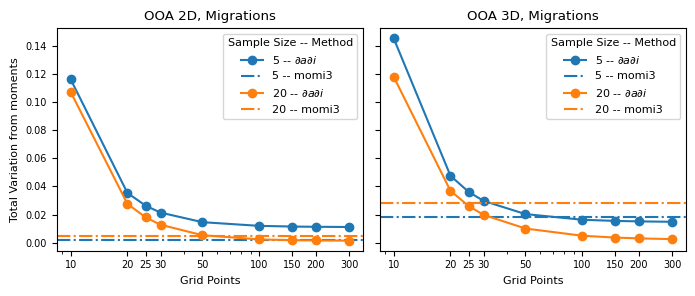

In [109]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(7, 3))
axs = iter([ax1, ax2])
for ndemes in [2, 3]:
    ax = next(axs)
    for ss in [5, 20]:
        tvs = []
        i = 0
        for pts in PTS:
            try:
                tvs.append(get_TV(ESFS['dadi'][ss, ndemes, pts], ESFS['moments'][ss, ndemes]))
                i += 1
            except:
                pass

        x = PTS[:i]
        tv_momi = get_TV(ESFS['momi3'][ss, ndemes], ESFS['moments'][ss, ndemes])
        a = ax.plot(x, tvs, 'o-', label=f'{ss} -- $\partial a \partial i$')
        c = a[0].get_color()
        ax.axhline(tv_momi, linestyle='-.', color=c, label=f'{ss} -- momi3')
        ax.set_xscale('log')
        ax.set_xticks(x, x)
    ax.set_xlabel('Grid Points')
    ax.set_title(f'OOA {ndemes}D, Migrations')
    legend = ax.legend()
    legend.set_title('Sample Size -- Method')
ax1.set_ylabel('Total Variation from moments')

figure_name = 'dadi_pts'

plt.tight_layout()
plt.savefig(f"../Enes-s-Dissertation/figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

In [ ]:
figure_name = 'dadi_pts'

plt.tight_layout()
plt.savefig(f"../Enes-s-Dissertation/figures/chapter3/{figure_name}.pdf", format="pdf", bbox_inches="tight", dpi=600)

In [102]:
ss = 5
ndemes = 4
pts = 100
get_TV(ESFS['dadi'][ss, ndemes, pts], ESFS['moments'][ss, ndemes])

0.4377667421802951

In [105]:
ss = 5
ndemes = 5
pts = 30
get_TV(ESFS['dadi'][ss, ndemes, pts], ESFS['moments'][ss, ndemes])

0.531843285976449